# GA Optimasi Posisi Object 2D

GRID = 10 × 10

objek: Town hall, defense, storage, army

Aturan:
1. tidak boleh ada yang tumpang tindih

Setiap objek mempunyai posisi:
```
A = (x1, y1)
B = (x2, y2)
C = (x3, y3)
D = (x4, y4)
E = (x5, y5)
```

Individual
[
    (x, y, size),
    (x, y, size),
    ...
]

(x,y) menjadi koordinat pojok kiri bawah objek

In [51]:
import random
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [52]:
# =========================================
# 1. Parameter Genetic Algorithm
# =========================================

POPULATION_SIZE = 25
GENERATIONS = 150

GRID_SIZE = 44

MUTATION_RATE = 0.1

MIN_DISTANCE = 1
OVERLAP_PENALTY = 1000
BOUNDARY_PENALTY = 1000

OBJECT_SIZES = [
    4,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,2,2,1,1,1
    ]

NUMBER_OF_OBJECTS = len(OBJECT_SIZES)


In [53]:
# =========================================
# Fungsi Distance
# =========================================

def distance(point1, point2):

    x1, y1 = point1
    x2, y2 = point2

    return math.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2
    )
    
# =========================================
# Fungsi Overlap bangunan 2D
# =========================================
def is_overlap(pos1, size1, pos2, size2):

    x1, y1 = pos1
    x2, y2 = pos2

    return (
        x1 < x2 + size2 and
        x1 + size1 > x2 and
        y1 < y2 + size2 and
        y1 + size1 > y2
    )


# =========================================
# 2. Fungsi Fitness
# =========================================

def fitness(individual):

    total_distance = 0
    penalty = 0

    # -------------------------------------
    # 1. Jarak antar objek
    # -------------------------------------

    for i in range(NUMBER_OF_OBJECTS):

        for j in range(i + 1, NUMBER_OF_OBJECTS):

            distance_ij = distance(
                individual[i],
                individual[j]
            )

            total_distance += distance_ij


    # -------------------------------------
    # 2. Cek overlap
    # -------------------------------------

    for i in range(NUMBER_OF_OBJECTS):

        for j in range(i + 1, NUMBER_OF_OBJECTS):

            pos1 = individual[i]
            pos2 = individual[j]

            size1 = OBJECT_SIZES[i]
            size2 = OBJECT_SIZES[j]

            if is_overlap(
                pos1,
                size1,
                pos2,
                size2
            ):

                penalty += OVERLAP_PENALTY


    # -------------------------------------
    # 3. Cek keluar grid
    # -------------------------------------

    for i in range(NUMBER_OF_OBJECTS):

        x, y = individual[i]
        size = OBJECT_SIZES[i]

        if x + size > GRID_SIZE:
            penalty += BOUNDARY_PENALTY

        if y + size > GRID_SIZE:
            penalty += BOUNDARY_PENALTY

        if x < 0:
            penalty += BOUNDARY_PENALTY

        if y < 0:
            penalty += BOUNDARY_PENALTY


    return total_distance - penalty


# =========================================
# 3. Membuat individual
# =========================================

def create_individual():

    individual = []

    for size in OBJECT_SIZES:

        max_position = GRID_SIZE - size

        x = random.randint(
            0,
            max_position
        )

        y = random.randint(
            0,
            max_position
        )

        individual.append((x, y))

    return individual

In [54]:
# =========================================
# 5. Membuat population
# =========================================

def create_population():
    return [
        create_individual()
        for _ in range(POPULATION_SIZE)
    ]


# =========================================
# 6. Selection
# =========================================

def selection(population):
    population_sorted = sorted(
        population,
        key=fitness,
        reverse=True
    )

    # Ambil 50% terbaik
    return population_sorted[:POPULATION_SIZE // 2]


# =========================================
# 7. Crossover
# =========================================
def crossover(parent1, parent2):

    child1 = []
    child2 = []

    for i in range(NUMBER_OF_OBJECTS):

        if random.random() < 0.5:

            child1.append(parent1[i])
            child2.append(parent2[i])

        else:

            child1.append(parent2[i])
            child2.append(parent1[i])

    return child1, child2

# =========================================
# 8. Mutation
# =========================================
def mutation(individual):

    for i in range(NUMBER_OF_OBJECTS):

        if random.random() < MUTATION_RATE:

            size = OBJECT_SIZES[i]

            max_position = GRID_SIZE - size

            x = random.randint(
                0,
                max_position
            )

            y = random.randint(
                0,
                max_position
            )

            individual[i] = (x, y)

    return individual




Generation 01 | Fitness = 5264.84 | Position = [(13, 38), (34, 1), (23, 34), (0, 9), (21, 28), (35, 10), (2, 19), (17, 40), (11, 18), (25, 28), (39, 36), (31, 21), (26, 36), (30, 15), (13, 1), (17, 21), (32, 5), (7, 32), (26, 40), (0, 36), (8, 22), (15, 43)]
Generation 02 | Fitness = 5264.84 | Position = [(13, 38), (34, 1), (23, 34), (0, 9), (21, 28), (35, 10), (2, 19), (17, 40), (11, 18), (25, 28), (39, 36), (31, 21), (26, 36), (30, 15), (13, 1), (17, 21), (32, 5), (7, 32), (26, 40), (0, 36), (8, 22), (15, 43)]
Generation 03 | Fitness = 5391.25 | Position = [(25, 18), (18, 37), (41, 16), (37, 39), (31, 9), (19, 3), (11, 1), (12, 33), (21, 19), (19, 30), (2, 7), (23, 22), (15, 25), (33, 12), (24, 0), (2, 1), (20, 41), (10, 36), (34, 21), (15, 36), (39, 42), (8, 35)]
Generation 04 | Fitness = 5647.44 | Position = [(7, 16), (34, 1), (14, 4), (33, 35), (9, 26), (15, 1), (2, 19), (5, 26), (7, 4), (10, 38), (31, 40), (31, 21), (26, 36), (30, 15), (1, 9), (17, 8), (32, 5), (39, 0), (26, 40),

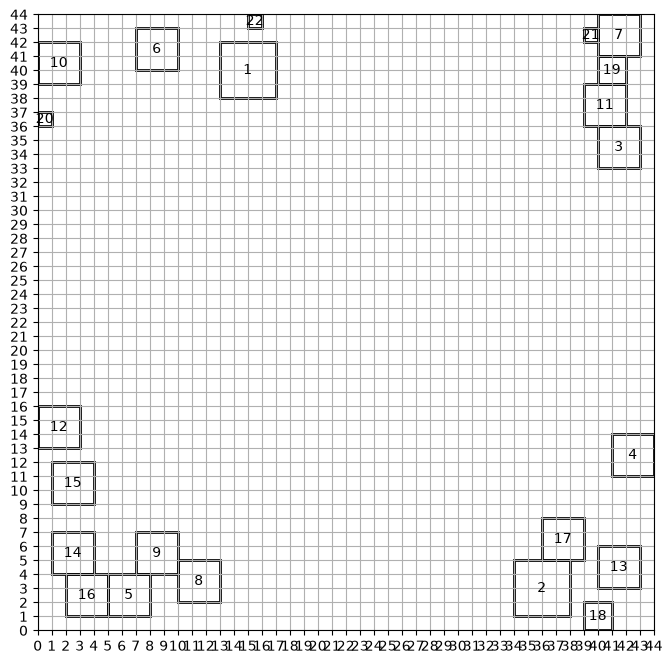

In [55]:
# =========================================
# 9. Genetic Algorithm
# =========================================

population = create_population()


for generation in range(GENERATIONS):

    # -----------------------------
    # Evaluasi
    # -----------------------------

    best = max(
        population,
        key=fitness
    )

    print(
        f"Generation {generation + 1:02d} | "
        f"Fitness = {fitness(best):.2f} | "
        f"Position = {best}"
    )


    # -----------------------------
    # Selection
    # -----------------------------

    parents = selection(population)


    # -----------------------------
    # Membuat population baru
    # -----------------------------

    new_population = parents.copy()


    while len(new_population) < POPULATION_SIZE:

        parent1, parent2 = random.sample(parents, 2)

        child1, child2 = crossover(
            parent1,
            parent2
        )

        child1 = mutation(child1)
        child2 = mutation(child2)

        new_population.append(child1)

        if len(new_population) < POPULATION_SIZE:
            new_population.append(child2)


    population = new_population


# =========================================
# 10. Hasil akhir
# =========================================

best = max(
    population,
    key=fitness
)

print("\nHasil Akhir")

print("Position :", best)
print("Fitness  :", fitness(best))



# =========================================
# 11. Visualisasi
# =========================================

fig, ax = plt.subplots(figsize=(8, 8))

for i, (x, y) in enumerate(best):

    size = OBJECT_SIZES[i]

    rectangle = Rectangle(
        (x, y),
        size,
        size,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    ax.text(
        x + size / 2,
        y + size / 2,
        f"{i + 1}",
        ha="center",
        va="center"
    )


ax.set_xlim(0, GRID_SIZE)
ax.set_ylim(0, GRID_SIZE)

ax.set_xticks(range(GRID_SIZE + 1))
ax.set_yticks(range(GRID_SIZE + 1))

ax.grid(True)

ax.set_aspect("equal")

plt.show()